<h1> <b> Configuraciones y rutas

In [1]:
# Librerías
import sys
import torch
import numpy as np
import random
import copy
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn as nn
import math
import importlib

# Importes
from pathlib import Path
sys.path.append(str(Path(".").resolve()))
from modelo_head import crear_encoder, crear_cabeza
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.metrics import (roc_auc_score, confusion_matrix, f1_score, recall_score, precision_score)

# Recargar agregacion para asegurar versión actualizada
import agregacion_head
importlib.reload(agregacion_head)
from agregacion_head import agregar_pesos

# Semilla
SEED = 42
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

# Dispositivo
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {DEVICE}")

Dispositivo: cuda


In [3]:
# Rutas por centro
BASE_DIR = Path("..")

CENTROS = {
    "center_1": {
        "train": BASE_DIR / "preprocesamiento/output/center_1/preprocesamiento_train",
        "test" : BASE_DIR / "preprocesamiento/output/center_1/preprocesamiento_test",
    },
    "center_2": {
        "train": BASE_DIR / "preprocesamiento/output/center_2/preprocesamiento_train",
        "test" : BASE_DIR / "preprocesamiento/output/center_2/preprocesamiento_test",
    },
    "center_3": {
        "train": BASE_DIR / "preprocesamiento/output/center_3/preprocesamiento_train",
        "test" : BASE_DIR / "preprocesamiento/output/center_3/preprocesamiento_test",
    },
    "center_4": {
        "train": BASE_DIR / "preprocesamiento/output/center_4/preprocesamiento_train",
        "test" : BASE_DIR / "preprocesamiento/output/center_4/preprocesamiento_test",
    },
}

# Hiperparámetros
BATCH_SIZE       = 16
EPOCHS_LOCAL     = 20     # épocas que entrena cada centro por ronda
RONDAS           = 30    # rondas de comunicación federada
LR               = 1e-4
PACIENCIA        = 10     # early stopping

# Directorio de pesos
PESOS_DIR = Path("pesos_sin_head")
PESOS_DIR.mkdir(exist_ok=True)
(PESOS_DIR / "cabezas").mkdir(exist_ok=True) 

# Verificar que los centros existen
for nombre, rutas in CENTROS.items():
    train_ok = rutas["train"].exists()
    test_ok  = rutas["test"].exists()
    print(f"  {nombre} — train: {'Ok' if train_ok else 'Bad'} | test: {'Ok' if test_ok else 'Bad'}")

  center_1 — train: Ok | test: Ok
  center_2 — train: Ok | test: Ok
  center_3 — train: Ok | test: Ok
  center_4 — train: Ok | test: Ok


<h1><b> Dataset y dataloader

In [4]:
# Dataset y DataLoader personalizados para nuestros archivos .npy
class StrokeDataset(Dataset):

    def __init__(self, archivos):
        # Guardamos las rutas de los archivos .npy
        self.archivos = archivos

    def __len__(self):
        # El número de muestras es el número de archivos .npy
        return len(self.archivos)

    def __getitem__(self, idx):
        # Cargar imagen
        ruta   = self.archivos[idx]
        imagen = np.load(ruta).astype(np.float32)
        imagen = torch.from_numpy(imagen)

        nombre = ruta.stem
        # contiene "STROKE" para positivos y no lo contiene para negativos
        label  = 1 if "STROKE" in nombre else 0

        # Retorno como tensor de PyTorch del label (0 o 1) y la imagen
        return imagen, torch.tensor(label, dtype=torch.float32)

# Función para cargar los datos de un centro
def cargar_centro(rutas_centro):

    # Listar y ordenar los archivos .npy en train y test
    archivos_train = sorted(rutas_centro["train"].glob("*.npy"))
    archivos_test  = sorted(rutas_centro["test"].glob("*.npy"))

    # Crear datasets
    dataset_train = StrokeDataset(archivos_train)
    dataset_test  = StrokeDataset(archivos_test)

    # Crear dataloaders
    loader_train = DataLoader(dataset_train, batch_size=BATCH_SIZE, shuffle=True)
    loader_test  = DataLoader(dataset_test,  batch_size=BATCH_SIZE, shuffle=False)

    # Retornar los datasets y dataloaders
    return {
        "dataset_train": dataset_train,
        "dataset_test" : dataset_test,
        "loader_train" : loader_train,
        "loader_test"  : loader_test,
    }

# Cargar datos de todos los centros
datos_centros = {}

for nombre, rutas in CENTROS.items():
    datos_centros[nombre] = cargar_centro(rutas)


# Verificación
print(f"{'Centro':<12} {'Train':>8} {'Test':>8}")
print("-" * 30)
for nombre, datos in datos_centros.items():
    n_train = len(datos["dataset_train"])
    n_test  = len(datos["dataset_test"])
    print(f"{nombre:<12} {n_train:>8} {n_test:>8}")

Centro          Train     Test
------------------------------
center_1         3040      760
center_2          960      240
center_3          679      171
center_4         1280      320


In [5]:
def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

# Definir esto una vez fuera de cargar_centro
g = torch.Generator()
g.manual_seed(SEED)

In [6]:
# Train divido en: 80% para entrenamiento y 20% para validación dentro de cada centro
def split_train_val(dataset, seed=SEED):
    val_size   = int(len(dataset) * 0.2)
    train_size = len(dataset) - val_size
    return random_split(dataset, [train_size, val_size],
                        generator=torch.Generator().manual_seed(seed))


# Crear loaders con split para cada centro
for nombre, datos in datos_centros.items():
    train_split, val_split = split_train_val(datos["dataset_train"])

    datos["loader_train"] = DataLoader(
        train_split,
        batch_size=BATCH_SIZE,
        shuffle=True,
        worker_init_fn=seed_worker,
        generator=g
    )
    datos["loader_val"]   = DataLoader(val_split,   batch_size=BATCH_SIZE, shuffle=False)
    datos["n_train"]      = len(train_split)
    datos["n_val"]        = len(val_split)

print(f"{'Centro':<12} {'Train':>8} {'Val':>8}")
print("-" * 30)
for nombre, datos in datos_centros.items():
    print(f"{nombre:<12} {datos['n_train']:>8} {datos['n_val']:>8}")

Centro          Train      Val
------------------------------
center_1         2432      608
center_2          768      192
center_3          544      135
center_4         1024      256


<h1><b> Modelo global

In [7]:
# Modelo global
set_seed(SEED)
encoder_global = crear_encoder().to(DEVICE)

# Cabezas locales por centro 
cabezas_centros = {nombre: crear_cabeza().to(DEVICE) for nombre in CENTROS}

# Ruta donde guardar el mejor modelo global
MEJOR_ENCODER_PATH = PESOS_DIR / "encoder_global_mejor_fedavg.pth"
CABEZAS_DIR        = PESOS_DIR / "cabezas" 

params_encoder = sum(p.numel() for p in encoder_global.parameters())
params_cabeza  = sum(p.numel() for p in list(cabezas_centros.values())[0].parameters())

print(f"Parámetros encoder : {params_encoder:,}")
print(f"Parámetros cabeza  : {params_cabeza:,}")
print(f"Dispositivo        : {DEVICE}")

Parámetros encoder : 11,218,312
Parámetros cabeza  : 513
Dispositivo        : cuda


<h1><b> Entrenamiento local por centro para federado

In [8]:
# Funciones de pérdida por centro
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0):
        super().__init__()
        self.gamma = gamma

    def forward(self, logits, targets):
        bce   = nn.functional.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        probs = torch.sigmoid(logits)
        pt    = torch.where(targets == 1, probs, 1 - probs)
        loss  = ((1 - pt) ** self.gamma) * bce
        return loss.mean()

In [9]:
LOSS_POR_CENTRO = {
    "center_1": nn.BCEWithLogitsLoss(),
    "center_2": nn.BCEWithLogitsLoss(),
    "center_3": FocalLoss(gamma=2.0),
    "center_4": nn.BCEWithLogitsLoss(pos_weight=torch.tensor([588/692]).to(DEVICE)),
}

In [10]:
def entrenar_centro(nombre, encoder_global, cabeza_centro, loader_train, loader_val, epochs):
    """
    Entrena localmente y retorna los mejores pesos
    y el val_loss correspondiente.
    """
    # Copia local del modelo global — no modificamos el global
    encoder_local = copy.deepcopy(encoder_global)
    cabeza_local  = copy.deepcopy(cabeza_centro)
    criterio      = LOSS_POR_CENTRO[nombre] # es mejor para clasificación binaria con logits

    # Optimizador para el modelo local
    optimizer = torch.optim.AdamW(
        list(encoder_local.parameters()) + list(cabeza_local.parameters()),
        lr=LR
    )

    # Variables para guardar la mejor época local
    mejor_val_loss = float("inf")
    mejor_val_auc  = 0.0
    mejor_val_acc  = 0.0
    mejores_pesos_encoder = None
    mejores_pesos_cabeza  = None

    for epoca in range(epochs):
        # Train
        encoder_local.train()
        cabeza_local.train()

        train_loss, train_correctos = 0.0, 0

        for imagenes, labels in loader_train:

            imagenes = imagenes.to(DEVICE)
            labels   = labels.to(DEVICE).unsqueeze(1)

            # zero_grad es importante para no acumular gradientes entre lotes
            optimizer.zero_grad()

            # forward + backward
            embedding = encoder_local(imagenes)   # [batch, 512]
            salida    = cabeza_local(embedding)    # [batch, 1]

            loss   = criterio(salida, labels)
            loss.backward()
            # actualizar pesos locales
            optimizer.step()

            # Acumular métricas para esta época
            train_loss      += loss.item()
            preds            = (torch.sigmoid(salida) >= 0.5).float()
            train_correctos += (preds == labels).sum().item()

        # Val
        encoder_local.eval()
        cabeza_local.eval()

        val_loss, val_correctos = 0.0, 0
        todas_probs  = []
        todos_labels = []

        # No necesitamos gradientes para la validación
        with torch.no_grad():
            for imagenes, labels in loader_val:
                imagenes  = imagenes.to(DEVICE)
                labels    = labels.to(DEVICE).unsqueeze(1)
                embedding = encoder_local(imagenes)
                salida    = cabeza_local(embedding)
                loss      = criterio(salida, labels)
                probs     = torch.sigmoid(salida).squeeze(1).cpu().numpy()

                val_loss      += loss.item()
                preds          = (torch.sigmoid(salida) >= 0.5).float()
                val_correctos += (preds == labels).sum().item()
                todas_probs.extend(probs)
                todos_labels.extend(labels.squeeze(1).cpu().numpy())
        
        # Promedio de métricas por época
        train_loss /= len(loader_train)
        val_loss   /= len(loader_val)
        train_acc   = train_correctos / len(loader_train.dataset)
        val_acc     = val_correctos   / len(loader_val.dataset)
        val_auc     = roc_auc_score(todos_labels, todas_probs)

        print(f"      [{nombre}] época {epoca+1:02d}/{epochs} — "
              f"train_loss: {train_loss:.4f} acc: {train_acc:.4f} | "
              f"val_loss: {val_loss:.4f} acc: {val_acc:.4f} | auc: {val_auc:.4f}")
        
        
        # Guardar mejor época local por AUC
        if val_auc > mejor_val_auc:
            mejor_val_loss        = val_loss
            mejor_val_acc         = val_acc
            mejor_val_auc         = val_auc
            mejores_pesos_encoder = copy.deepcopy(encoder_local.state_dict())
            mejores_pesos_cabeza  = copy.deepcopy(cabeza_local.state_dict())
            print(f"        → mejor época local: {epoca+1} | auc: {mejor_val_auc:.4f}")

    return mejores_pesos_encoder, mejores_pesos_cabeza, mejor_val_loss, mejor_val_acc, mejor_val_auc

# **Entrenamiento Federado (FedAvg) - Sin Cabezas**

In [11]:
# Rondas federadas

# Variables para seguimiento de la mejor ronda global
mejor_val_global  = 0.0
rondas_sin_mejora = 0
total_muestras    = sum(d["n_train"] for d in datos_centros.values())

historial = {"ronda": [], "val_auc": []}

# Entrenamiento federado
for ronda in range(1, RONDAS + 1):

    print(f"\n{'='*60}")
    print(f"  RONDA {ronda}/{RONDAS}")
    print(f"{'='*60}")

    set_seed(SEED + ronda)

    # Reiniciar generator al inicio de cada ronda
    g = torch.Generator()
    g.manual_seed(SEED + ronda)  # seed distinta pero fija por ronda

    # Recrear loader_train con el nuevo generator
    for nombre, datos in datos_centros.items():
        datos["loader_train"] = DataLoader(
            datos["loader_train"].dataset,
            batch_size=BATCH_SIZE,
            shuffle=True,
            worker_init_fn=seed_worker,
            generator=g
        )

    pesos_encoder_centros = []   # solo encoders van a FedAvg
    val_losses            = []
    val_aucs              = []
    muestras_centros      = []


    # Entrenamiento local por centro
    for nombre, datos in datos_centros.items():
        print(f"\n  Centro: {nombre}")
        set_seed(SEED + ronda)

        pesos_encoder, pesos_cabeza, val_loss, val_acc, val_auc = entrenar_centro(
            nombre,
            encoder_global,
            cabezas_centros[nombre],   # cabeza persistente por centro
            datos["loader_train"],
            datos["loader_val"],
            EPOCHS_LOCAL
        )

        pesos_encoder_centros.append(pesos_encoder)  # para FedAvg
        cabezas_centros[nombre].load_state_dict(pesos_cabeza)  # actualiza cabeza local
        val_losses.append(val_loss)
        val_aucs.append(val_auc)
        muestras_centros.append(datos["n_train"])

    # FedAvg
    pesos_globales = agregar_pesos(pesos_encoder_centros, muestras_centros)
    encoder_global.load_state_dict(pesos_globales)

    # Val global ponderada
    val_global = sum(
        va * (n / total_muestras)
        for va, n in zip(val_aucs, muestras_centros)
    )

    historial["ronda"].append(ronda)
    historial["val_auc"].append(val_global)

    print(f"\n  {'─'*55}")
    print(f"  Ronda {ronda} — val_auc global: {val_global:.4f}")


    # Guardar mejor modelo global
    if val_global > mejor_val_global:
        mejor_val_global  = val_global
        rondas_sin_mejora = 0
        torch.save(encoder_global.state_dict(), MEJOR_ENCODER_PATH)
        print(f"  Mejor encoder global guardado (val_auc: {mejor_val_global:.4f})")
    else:
        rondas_sin_mejora += 1
        print(f"  Sin mejora {rondas_sin_mejora}/{PACIENCIA}")

    # Early stopping
    if rondas_sin_mejora >= PACIENCIA:
        print(f"\n  Early stopping en ronda {ronda}")
        break


print(f"\n{'='*60}")
print(f"Entrenamiento federado finalizado")
print(f"Mejor val_auc global : {mejor_val_global:.4f}")
print(f"Encoder guardado en  : {MEJOR_ENCODER_PATH}")


  RONDA 1/30

  Centro: center_1
      [center_1] época 01/20 — train_loss: 0.2237 acc: 0.9054 | val_loss: 0.0802 acc: 0.9720 | auc: 0.9959
        → mejor época local: 1 | auc: 0.9959
      [center_1] época 02/20 — train_loss: 0.0673 acc: 0.9762 | val_loss: 0.0662 acc: 0.9819 | auc: 0.9965
        → mejor época local: 2 | auc: 0.9965
      [center_1] época 03/20 — train_loss: 0.0192 acc: 0.9938 | val_loss: 0.0851 acc: 0.9720 | auc: 0.9969
        → mejor época local: 3 | auc: 0.9969
      [center_1] época 04/20 — train_loss: 0.0238 acc: 0.9926 | val_loss: 0.0563 acc: 0.9786 | auc: 0.9990
        → mejor época local: 4 | auc: 0.9990
      [center_1] época 05/20 — train_loss: 0.0202 acc: 0.9926 | val_loss: 0.1468 acc: 0.9605 | auc: 0.9982
      [center_1] época 06/20 — train_loss: 0.0186 acc: 0.9938 | val_loss: 0.0493 acc: 0.9819 | auc: 0.9989
      [center_1] época 07/20 — train_loss: 0.0104 acc: 0.9955 | val_loss: 0.0179 acc: 0.9951 | auc: 0.9996
        → mejor época local: 7 | auc:

<h1><b> Entrenamiento local - Heads

In [12]:
# Entrenamiento local desde cero por centro
# Encoder + cabeza nuevos, nos quedamos solo con la cabeza

for nombre, datos in datos_centros.items():

    print(f"\n{'='*60}")
    print(f"  Centro: {nombre}")
    print(f"{'='*60}")

    set_seed(SEED)

    # Crear encoder y cabeza desde cero — sin cargar nada del federado
    encoder_local = crear_encoder().to(DEVICE)
    cabeza_local  = crear_cabeza().to(DEVICE)

    criterio  = LOSS_POR_CENTRO[nombre]
    optimizer = torch.optim.AdamW(
        list(encoder_local.parameters()) + list(cabeza_local.parameters()),
        lr=LR
    )

    mejor_val_auc        = 0.0
    mejores_pesos_cabeza = None

    for epoca in range(EPOCHS_LOCAL):

        # Train
        encoder_local.train()
        cabeza_local.train()

        train_loss, train_correctos = 0.0, 0

        for imagenes, labels in datos["loader_train"]:
            imagenes = imagenes.to(DEVICE)
            labels   = labels.to(DEVICE).unsqueeze(1)

            optimizer.zero_grad()
            embedding = encoder_local(imagenes)
            salida    = cabeza_local(embedding)
            loss      = criterio(salida, labels)
            loss.backward()
            optimizer.step()

            train_loss      += loss.item()
            preds            = (torch.sigmoid(salida) >= 0.5).float()
            train_correctos += (preds == labels).sum().item()

        # Val
        encoder_local.eval()
        cabeza_local.eval()

        val_loss, val_correctos = 0.0, 0
        todas_probs  = []
        todos_labels = []

        with torch.no_grad():
            for imagenes, labels in datos["loader_val"]:
                imagenes  = imagenes.to(DEVICE)
                labels    = labels.to(DEVICE).unsqueeze(1)
                embedding = encoder_local(imagenes)
                salida    = cabeza_local(embedding)
                loss      = criterio(salida, labels)
                probs     = torch.sigmoid(salida).squeeze(1).cpu().numpy()

                val_loss      += loss.item()
                preds          = (torch.sigmoid(salida) >= 0.5).float()
                val_correctos += (preds == labels).sum().item()
                todas_probs.extend(probs)
                todos_labels.extend(labels.squeeze(1).cpu().numpy())

        train_loss /= len(datos["loader_train"])
        val_loss   /= len(datos["loader_val"])
        train_acc   = train_correctos / len(datos["loader_train"].dataset)
        val_acc     = val_correctos   / len(datos["loader_val"].dataset)
        val_auc     = roc_auc_score(todos_labels, todas_probs)

        print(f"  época {epoca+1:02d}/{EPOCHS_LOCAL} — "
              f"train_loss: {train_loss:.4f} acc: {train_acc:.4f} | "
              f"val_loss: {val_loss:.4f} acc: {val_acc:.4f} | auc: {val_auc:.4f}")

        # Guardar mejor cabeza por AUC
        if val_auc > mejor_val_auc:
            mejor_val_auc        = val_auc
            mejores_pesos_cabeza = copy.deepcopy(cabeza_local.state_dict())
            print(f"    → mejor época: {epoca+1} | auc: {mejor_val_auc:.4f}")

    # Guardar solo la cabeza — el encoder se descarta
    torch.save(mejores_pesos_cabeza, CABEZAS_DIR / f"{nombre}_head.pth")
    print(f"\n  Cabeza guardada: {nombre}_head.pth | mejor auc: {mejor_val_auc:.4f}")

print(f"\n{'='*60}")
print(f"Entrenamiento local finalizado")
print(f"Cabezas guardadas en: {CABEZAS_DIR}")


  Centro: center_1
  época 01/20 — train_loss: 0.2225 acc: 0.9083 | val_loss: 0.0937 acc: 0.9622 | auc: 0.9950
    → mejor época: 1 | auc: 0.9950
  época 02/20 — train_loss: 0.0531 acc: 0.9840 | val_loss: 0.0734 acc: 0.9720 | auc: 0.9975
    → mejor época: 2 | auc: 0.9975
  época 03/20 — train_loss: 0.0352 acc: 0.9873 | val_loss: 0.0565 acc: 0.9819 | auc: 0.9973
  época 04/20 — train_loss: 0.0113 acc: 0.9967 | val_loss: 0.0518 acc: 0.9836 | auc: 0.9983
    → mejor época: 4 | auc: 0.9983
  época 05/20 — train_loss: 0.0137 acc: 0.9951 | val_loss: 0.0530 acc: 0.9852 | auc: 0.9967
  época 06/20 — train_loss: 0.0218 acc: 0.9938 | val_loss: 0.1083 acc: 0.9539 | auc: 0.9967
  época 07/20 — train_loss: 0.0065 acc: 0.9971 | val_loss: 0.0494 acc: 0.9918 | auc: 0.9958
  época 08/20 — train_loss: 0.0215 acc: 0.9930 | val_loss: 0.0751 acc: 0.9819 | auc: 0.9957
  época 09/20 — train_loss: 0.0055 acc: 0.9988 | val_loss: 0.0267 acc: 0.9934 | auc: 0.9992
    → mejor época: 9 | auc: 0.9992
  época 10/2

<h1><b> Evaluación

In [13]:
# Cargar el mejor encoder global
encoder_global.load_state_dict(torch.load(MEJOR_ENCODER_PATH, map_location=DEVICE))
encoder_global.eval()

# Cargar las cabezas locales guardadas
for nombre in CENTROS:
    cabezas_centros[nombre].load_state_dict(
        torch.load(CABEZAS_DIR / f"{nombre}_head.pth", map_location=DEVICE)
    )
    cabezas_centros[nombre].eval()


def evaluar_centro(nombre, encoder, cabeza, loader_test):
    todos_labels = []
    todos_probs  = []
    todos_preds  = []

    with torch.no_grad():
        for imagenes, labels in loader_test:
            imagenes  = imagenes.to(DEVICE)
            embedding = encoder(imagenes)
            salida    = cabeza(embedding)
            probs     = torch.sigmoid(salida).squeeze(1).cpu().numpy()
            preds     = (probs >= 0.5).astype(int)

            todos_labels.extend(labels.numpy().astype(int))
            todos_probs.extend(probs)
            todos_preds.extend(preds)

    auc           = roc_auc_score(todos_labels, todos_probs)
    f1            = f1_score(todos_labels, todos_preds)
    sensibilidad  = recall_score(todos_labels, todos_preds)
    especificidad = recall_score(todos_labels, todos_preds, pos_label=0)
    precision     = precision_score(todos_labels, todos_preds)
    accuracy      = sum(p == l for p, l in zip(todos_preds, todos_labels)) / len(todos_labels)
    cm            = confusion_matrix(todos_labels, todos_preds)

    return {
        "auc"          : auc,
        "f1"           : f1,
        "sensibilidad" : sensibilidad,
        "especificidad": especificidad,
        "precision"    : precision,
        "accuracy"     : accuracy,
        "cm"           : cm,
        "labels"       : todos_labels,
        "preds"        : todos_preds,
    }


# Evaluar cada centro con encoder global + su cabeza local
resultados = {}

for nombre, datos in datos_centros.items():
    resultados[nombre] = evaluar_centro(
        nombre,
        encoder_global,
        cabezas_centros[nombre],
        datos["loader_test"]
    )

# Métricas por centro
print(f"\n{'='*65}")
print(f"  EVALUACIÓN FINAL — TEST SET POR CENTRO")
print(f"{'='*65}")
print(f"{'Métrica':<18} {'Center 1':>10} {'Center 2':>10} {'Center 3':>10} {'Center 4':>10}")
print(f"{'─'*65}")

metricas  = ["auc", "accuracy", "f1", "sensibilidad", "especificidad", "precision"]
nombres_m = ["AUC-ROC", "Accuracy", "F1-Score", "Sensibilidad", "Especificidad", "Precisión"]

for metrica, nombre_m in zip(metricas, nombres_m):
    vals = [resultados[c][metrica] for c in datos_centros]
    print(f"  {nombre_m:<16} {vals[0]:>10.4f} {vals[1]:>10.4f} {vals[2]:>10.4f} {vals[3]:>10.4f}")

print(f"{'='*65}")


  EVALUACIÓN FINAL — TEST SET POR CENTRO
Métrica              Center 1   Center 2   Center 3   Center 4
─────────────────────────────────────────────────────────────────
  AUC-ROC              0.9728     0.9765     0.1294     0.2984
  Accuracy             0.9316     0.9250     0.1871     0.3969
  F1-Score             0.9278     0.9318     0.2944     0.4987
  Sensibilidad         0.8789     0.8786     0.2710     0.5549
  Especificidad        0.9842     0.9900     0.0469     0.2109
  Precisión            0.9824     0.9919     0.3222     0.4528


<h1><b> Probabilidades centro 5

In [17]:
# Rutas center_5
CENTER_5_TEST = BASE_DIR / "preprocesamiento/output/center_5/preprocesamiento_test"

# Dataset y loader
archivos_test_c5 = sorted(CENTER_5_TEST.glob("*.npy"))
dataset_c5       = StrokeDataset(archivos_test_c5)
loader_c5        = DataLoader(dataset_c5, batch_size=BATCH_SIZE, shuffle=False)

# Subcarpeta de salida
CENTER_5_DIR = PESOS_DIR / "center_5"
CENTER_5_DIR.mkdir(exist_ok=True)

print(f"Center 5 — muestras test: {len(dataset_c5)}")

Center 5 — muestras test: 257


In [18]:
import pandas as pd

encoder_global.eval()

for nombre_centro, cabeza in cabezas_centros.items():
    cabeza.eval()

    nombres_archivos = []
    probabilidades   = []

    with torch.no_grad():
        for i, (imagenes, _) in enumerate(loader_c5):
            imagenes  = imagenes.to(DEVICE)
            embedding = encoder_global(imagenes)
            salida    = cabeza(embedding)
            probs     = torch.sigmoid(salida).squeeze(1).cpu().numpy()

            idx_inicio     = i * BATCH_SIZE
            batch_archivos = archivos_test_c5[idx_inicio: idx_inicio + len(imagenes)]
            nombres_archivos.extend([a.stem for a in batch_archivos])
            probabilidades.extend(probs.tolist())

    df = pd.DataFrame({
        "archivo"     : nombres_archivos,
        "probabilidad": probabilidades,
    })

    ruta_csv = CENTER_5_DIR / f"center_5_probs_{nombre_centro}_head.csv"
    df.to_csv(ruta_csv, index=False)
    print(f"  {nombre_centro} - {ruta_csv} ({len(df)} muestras)")

print(f"\nCSVs guardados en: {CENTER_5_DIR}")

  center_1 - pesos_sin_head\center_5\center_5_probs_center_1_head.csv (257 muestras)
  center_2 - pesos_sin_head\center_5\center_5_probs_center_2_head.csv (257 muestras)
  center_3 - pesos_sin_head\center_5\center_5_probs_center_3_head.csv (257 muestras)
  center_4 - pesos_sin_head\center_5\center_5_probs_center_4_head.csv (257 muestras)

CSVs guardados en: pesos_sin_head\center_5


Center 5 — muestras: 257


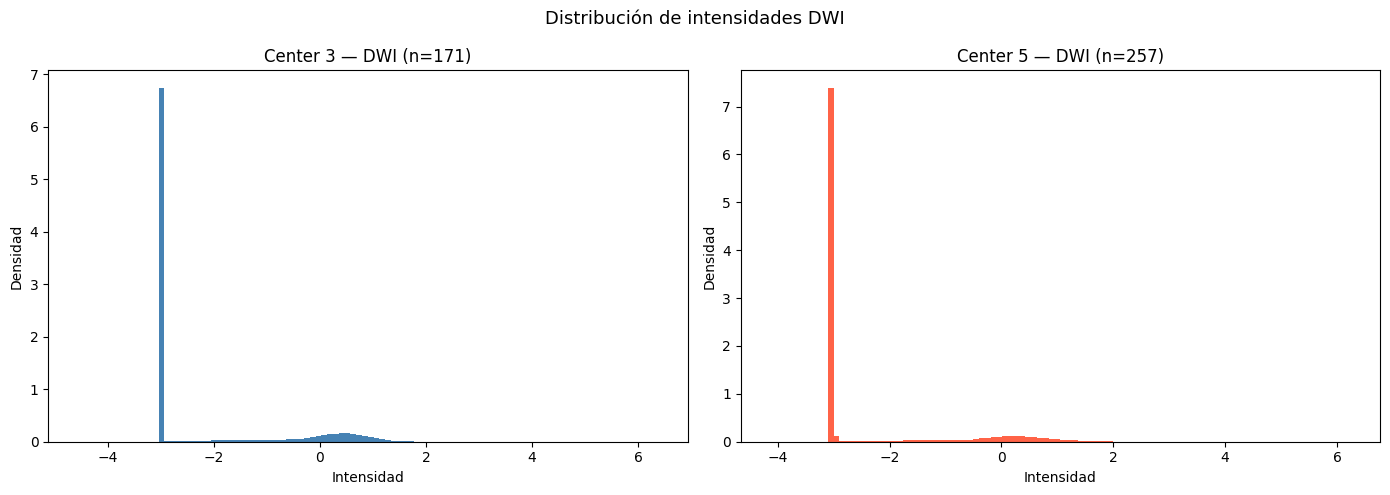

Center 3 — mean: -2.2336 | std: 1.3898 | min: -4.5737 | max: 6.3794
Center 5 — mean: -2.3580 | std: 1.3038 | min: -4.1431 | max: 6.2501


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

BASE_DIR         = Path("..")
BATCH_SIZE       = 16
archivos_test_c5 = sorted(
    (BASE_DIR / "preprocesamiento/output/center_5/preprocesamiento_test").glob("*.npy")
)

print(f"Center 5 — muestras: {len(archivos_test_c5)}")

def get_pixeles_dwi(archivos, n_max=None):
    """Extrae todos los píxeles del canal DWI (canal 0) de los archivos .npy"""
    pixeles = []
    archivos = archivos[:n_max] if n_max else archivos
    for ruta in archivos:
        img = np.load(ruta)  # [2, 112, 112]
        dwi = img[0].flatten()
        pixeles.extend(dwi.tolist())
    return np.array(pixeles)


# Archivos de center_3 y center_5
archivos_c3 = sorted(
    (BASE_DIR / "preprocesamiento/output/center_3/preprocesamiento_test").glob("*.npy")
)

pixeles_c3 = get_pixeles_dwi(archivos_c3)
pixeles_c5 = get_pixeles_dwi(archivos_test_c5)

# Histograma
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(pixeles_c3, bins=100, color="steelblue", density=True)
axes[0].set_title(f"Center 3 — DWI (n={len(archivos_c3)})")
axes[0].set_xlabel("Intensidad")
axes[0].set_ylabel("Densidad")

axes[1].hist(pixeles_c5, bins=100, color="tomato", density=True)
axes[1].set_title(f"Center 5 — DWI (n={len(archivos_test_c5)})")
axes[1].set_xlabel("Intensidad")
axes[1].set_ylabel("Densidad")

plt.suptitle("Distribución de intensidades DWI", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Center 3 — mean: {pixeles_c3.mean():.4f} | std: {pixeles_c3.std():.4f} | min: {pixeles_c3.min():.4f} | max: {pixeles_c3.max():.4f}")
print(f"Center 5 — mean: {pixeles_c5.mean():.4f} | std: {pixeles_c5.std():.4f} | min: {pixeles_c5.min():.4f} | max: {pixeles_c5.max():.4f}")

In [3]:
from scipy.stats import mannwhitneyu

BASE_DIR         = Path("..")
BATCH_SIZE       = 16
archivos_test_c5 = sorted(
    (BASE_DIR / "preprocesamiento/output/center_5/preprocesamiento_test").glob("*.npy")
)
archivos_c3 = sorted(
    (BASE_DIR / "preprocesamiento/output/center_3/preprocesamiento_test").glob("*.npy")
)

def get_pixeles_dwi(archivos, n_max=None):
    """Extrae todos los píxeles del canal DWI (canal 0) de los archivos .npy"""
    pixeles = []
    archivos = archivos[:n_max] if n_max else archivos
    for ruta in archivos:
        img = np.load(ruta)  # [2, 112, 112]
        dwi = img[0].flatten()
        pixeles.extend(dwi.tolist())
    return np.array(pixeles)

pixeles_c3 = get_pixeles_dwi(archivos_c3)
pixeles_c5 = get_pixeles_dwi(archivos_test_c5)

# Excluir fondo
UMBRAL_FONDO     = -2.5
pixeles_c3_brain = pixeles_c3[pixeles_c3 > UMBRAL_FONDO]
pixeles_c5_brain = pixeles_c5[pixeles_c5 > UMBRAL_FONDO]

print(f"Center 3 — píxeles cerebro: {len(pixeles_c3_brain):,}")
print(f"Center 5 — píxeles cerebro: {len(pixeles_c5_brain):,}")


print(f"\nCenter 3 — mean: {pixeles_c3_brain.mean():.4f} | std: {pixeles_c3_brain.std():.4f}")
print(f"Center 5 — mean: {pixeles_c5_brain.mean():.4f} | std: {pixeles_c5_brain.std():.4f}")

# Mann-Whitney U
stat, p_value = mannwhitneyu(pixeles_c3_brain, pixeles_c5_brain)

print(f"\nMann-Whitney U")
print(f"{'─'*35}")
print(f"  Estadístico U : {stat:,.0f}")
print(f"  p-value       : {p_value:.6f}")
print()
if p_value > 0.05:
    print(f"  → No hay diferencia significativa (p > 0.05)")
    print(f"     Las distribuciones son similares — center_5 es compatible con center_3")
else:
    print(f"  → Diferencia significativa (p < 0.05)")
    print(f"     Las distribuciones difieren entre centros")

Center 3 — píxeles cerebro: 544,902
Center 5 — píxeles cerebro: 689,524

Center 3 — mean: 0.0101 | std: 0.9231
Center 5 — mean: -0.0077 | std: 0.9583

Mann-Whitney U
───────────────────────────────────
  Estadístico U : 194,800,332,252
  p-value       : 0.000000

  → Diferencia significativa (p < 0.05)
     Las distribuciones difieren entre centros


In [4]:
from scipy.stats import wilcoxon

# Igualar tamaños muestreando aleatoriamente el más grande
np.random.seed(SEED)
n = min(len(pixeles_c3_brain), len(pixeles_c5_brain))
muestra_c3 = np.random.choice(pixeles_c3_brain, size=n, replace=False)
muestra_c5 = np.random.choice(pixeles_c5_brain, size=n, replace=False)

stat, p_value = wilcoxon(muestra_c3, muestra_c5)

print(f"Wilcoxon signed-rank test")
print(f"{'─'*35}")
print(f"  n muestras    : {n:,}")
print(f"  Estadístico W : {stat:,.0f}")
print(f"  p-value       : {p_value:.6f}")
print()
if p_value > 0.05:
    print(f"  → No hay diferencia significativa (p > 0.05)")
    print(f"     Las distribuciones son similares")
else:
    print(f"  → Diferencia significativa (p < 0.05)")
    print(f"     Las distribuciones difieren entre centros")

Wilcoxon signed-rank test
───────────────────────────────────
  n muestras    : 544,902
  Estadístico W : 71,992,105,382
  p-value       : 0.000000

  → Diferencia significativa (p < 0.05)
     Las distribuciones difieren entre centros
